In [1]:
import pandas as pd # 以pd别名导入Python数据分析模块
import re # 导入正则表达式模块，可进行模式匹配、搜索和替换
import numpy as np # 导入数值计算模块

import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
plt.rcParams['font.sans-serif'] = ['KaiTi']  #指定默认字体 SimHei黑体
plt.rcParams['axes.unicode_minus'] = False   #解决保存图像是负号'
import jieba

In [2]:
import gensim
from gensim import corpora
import matplotlib
import warnings
warnings.filterwarnings('ignore')  # To ignore all warnings that arise here to enhance clarity
 
from gensim.models.coherencemodel import CoherenceModel
from gensim.models.ldamodel import LdaModel

In [3]:
# 先将文档转化为一个二元列表，其中每个子列表代表一条评论：
PATH = "./review/apple_cutword.csv"

file_object = open(PATH, encoding = 'utf-8', errors = 'ignore').read().split('\n')  #一行行的读取内容

data_set=[]  #建立存储分词的列表
for i in range(len(file_object)):
    result=[]
    seg_list = file_object[i].split()
    for w in seg_list :  #读取每一行分词
        result.append(w)
    data_set.append(result)
print(data_set)

[['包装', '脏', '没事', '服务', '挺'], ['看着', '不错', '用用'], ['比较满意', '质量', '希望', '把关'], ['追剧', '一点点', '卡', '摸索', '中'], ['耗电', '掉电', '很快'], ['不用', '说', '性价比', '高', '提升', '中'], ['好用', '系统', '流畅', '外观', '材质', '蓝色', '手感', '棒', '质感', '特别', '喜欢', '信赖', '商城', '产品', '屏幕', '效果', '屏幕显示', '效果', '细腻', '显示', '清晰', '运行', '速度', '处理器', '运行', '速度', '手机', '快', '爱不释手', '轻薄', '程度', '薄', '经典', '款式', '特色', '口', '充电', '指纹', '触控', '解锁', '音质', '音效', '音量', '很大'], ['超级', '漂亮', '女儿', '喜欢', '运行', '速度', '女儿', '生日礼物', '爱不释手', '唯一', '粉色', '女儿', '喜欢', '公主', '粉', '漂亮', '漂亮'], ['颜色', '真的', '超', '喜欢', '打游戏', '四年', '砸', '电池', '确实', '耐用', '手头紧', '先顶', '有钱', '不错', '追', '追剧', '打打', '游戏', '看看书', '够用'], ['品牌', '值得', '信赖', '想', '入手', '趁有', '活动', '入手', '划算', '第天', '送货上门', '丝滑', '学习', '娱乐', '两不误'], ['全新', '未激活', '粉色', '超', '好看', '查', '序列号', '正品', '机子', '中', '速度', '很快', '很丝滑', '轻薄', '续航', '不错', '喜欢', '听歌', '打游戏', '家', '可冲'], ['性价比', '超高', '质量', '想象', '全新', '未', '拆封', '正品', '屏幕', '外观', '棒棒', '说', '下车', '满意', '满意'], ['自营', '旗舰店', '双十', '一做',

In [4]:
# 构建词典，语料向量化表示
dictionary = corpora.Dictionary(data_set)  # 构建词典
corpus = [dictionary.doc2bow(text) for text in data_set]  #表示为第几个单词出现了几次

In [5]:
# 一般用来评价LDA主题模型的指标有困惑度（perplexity）和主题一致性（coherence），困惑度越低或者一致性越高说明模型越好。
# 一些研究表明perplexity并不是一个好的指标，所以一般我用coherence来评价模型并选择最优主题，但下面代码两种方法我都用了。

#计算困惑度
def perplexity(num_topics):
    ldamodel = LdaModel(corpus, num_topics=num_topics, id2word = dictionary, passes=30)
    print(ldamodel.print_topics(num_topics=num_topics, num_words=15))
    print(ldamodel.log_perplexity(corpus))
    return ldamodel.log_perplexity(corpus)

#计算coherence
def coherence(num_topics):
    ldamodel = LdaModel(corpus, num_topics=num_topics, id2word = dictionary, passes=30,random_state = 1)
    print(ldamodel.print_topics(num_topics=num_topics, num_words=10))
    ldacm = CoherenceModel(model=ldamodel, texts=data_set, dictionary=dictionary, coherence='c_v')
    print(ldacm.get_coherence())
    return ldacm.get_coherence()

[(0, '0.017*"速度" + 0.017*"屏幕" + 0.015*"不错" + 0.014*"运行" + 0.012*"效果" + 0.011*"外观" + 0.011*"轻薄" + 0.011*"流畅" + 0.010*"快" + 0.009*"喜欢"')]
0.3486433923353377
[(0, '0.019*"不错" + 0.017*"物流" + 0.017*"质量" + 0.016*"喜欢" + 0.016*"价格" + 0.015*"满意" + 0.014*"很快" + 0.013*"快" + 0.012*"速度" + 0.012*"包装"'), (1, '0.032*"屏幕" + 0.026*"运行" + 0.022*"效果" + 0.022*"速度" + 0.021*"轻薄" + 0.019*"外观" + 0.019*"流畅" + 0.014*"材质" + 0.013*"性能" + 0.011*"不错"')]
0.6025333126076367
[(0, '0.020*"物流" + 0.020*"质量" + 0.018*"不错" + 0.018*"价格" + 0.017*"满意" + 0.014*"很快" + 0.014*"喜欢" + 0.014*"包装" + 0.013*"购买" + 0.013*"快"'), (1, '0.025*"性能" + 0.020*"流畅" + 0.015*"体验" + 0.013*"续航" + 0.011*"出色" + 0.010*"运行" + 0.010*"娱乐" + 0.010*"清晰" + 0.010*"办公" + 0.009*"视频"'), (2, '0.043*"屏幕" + 0.034*"速度" + 0.033*"运行" + 0.029*"效果" + 0.028*"轻薄" + 0.027*"外观" + 0.021*"材质" + 0.021*"不错" + 0.016*"程度" + 0.015*"音质"')]
0.7175540482959063
[(0, '0.027*"物流" + 0.026*"质量" + 0.021*"满意" + 0.019*"很快" + 0.019*"包装" + 0.018*"速度" + 0.018*"不错" + 0.017*"快" + 0.016*"购物" + 0.016

0.4970464668520089
[(0, '0.043*"价格" + 0.027*"优惠" + 0.027*"活动" + 0.019*"划算" + 0.017*"不错" + 0.017*"国补" + 0.014*"性价比" + 0.013*"高" + 0.013*"便宜" + 0.013*"快递"'), (1, '0.032*"性能" + 0.026*"流畅" + 0.021*"体验" + 0.017*"续航" + 0.016*"出色" + 0.014*"运行" + 0.014*"娱乐" + 0.014*"清晰" + 0.012*"屏幕" + 0.011*"芯片"'), (2, '0.048*"大小" + 0.041*"尺寸" + 0.040*"合适" + 0.038*"寸" + 0.022*"真的" + 0.019*"打游戏" + 0.018*"屏幕" + 0.017*"适合" + 0.016*"小巧" + 0.016*"一点"'), (3, '0.046*"不错" + 0.021*"学习" + 0.020*"孩子" + 0.020*"流畅" + 0.016*"屏幕" + 0.015*"系统" + 0.014*"感觉" + 0.014*"喜欢" + 0.012*"新" + 0.011*"够用"'), (4, '0.089*"特别" + 0.081*"喜欢" + 0.025*"好用" + 0.025*"超级" + 0.019*"爱" + 0.017*"颜色" + 0.014*"快" + 0.014*"流畅" + 0.013*"真的" + 0.012*"购买"'), (5, '0.032*"感谢" + 0.027*"当天" + 0.020*"全新" + 0.019*"时间" + 0.019*"双层" + 0.018*"流量" + 0.017*"第一" + 0.014*"送" + 0.013*"充电" + 0.012*"相比"'), (6, '0.018*"没" + 0.015*"感觉" + 0.012*"便携性" + 0.012*"手机" + 0.011*"屏幕" + 0.011*"小巧" + 0.010*"性能" + 0.010*"说" + 0.010*"边框" + 0.010*"质感"'), (7, '0.033*"速度" + 0.033*"很快" + 0.

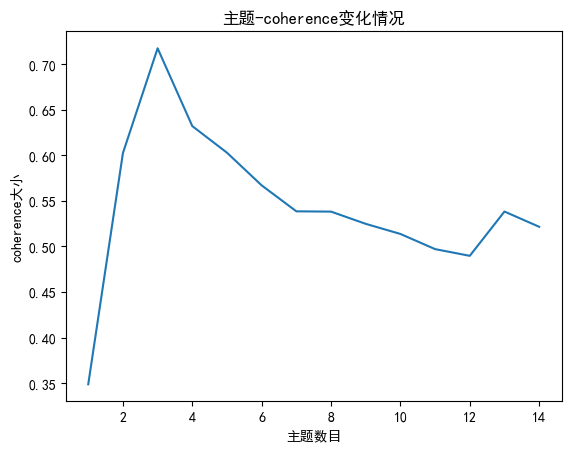

In [6]:
# 绘制主题-coherence曲线，选择最佳主题数
x = range(1,15)
# z = [perplexity(i) for i in x]  #如果想用困惑度就选这个
y = [coherence(i) for i in x]
plt.plot(x, y)
plt.xlabel('主题数目')
plt.ylabel('coherence大小')
plt.rcParams['font.sans-serif']=['SimHei']
matplotlib.rcParams['axes.unicode_minus']=False
plt.title('主题-coherence变化情况')
plt.show()

In [1]:
# 结果输出与可视化
# 通过上述主题评估，我们发现可以选择5作为主题个数，接下来我们可以再跑一次模型，设定主题数为5，并输出每个文档最有可能对应的主题

from gensim.models import LdaModel
import pandas as pd
from gensim.corpora import Dictionary
from gensim import corpora, models
import csv
import gensim
from gensim import corpora
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import warnings
warnings.filterwarnings('ignore')  # To ignore all warnings that arise here to enhance clarity
 
from gensim.models.coherencemodel import CoherenceModel
from gensim.models.ldamodel import LdaModel

In [2]:
# 先将文档转化为一个二元列表，其中每个子列表代表一条评论：
PATH = "./review/apple_cutword.csv"

file_object = open(PATH, encoding = 'utf-8', errors = 'ignore').read().split('\n')  #一行行的读取内容

data_set=[]  #建立存储分词的列表
for i in range(len(file_object)):
    result=[]
    seg_list = file_object[i].split()
    for w in seg_list :  #读取每一行分词
        result.append(w)
    data_set.append(result)
print(data_set)

[['包装', '脏', '没事', '服务', '挺'], ['看着', '不错', '用用'], ['比较满意', '质量', '希望', '把关'], ['追剧', '一点点', '卡', '摸索', '中'], ['耗电', '掉电', '很快'], ['不用', '说', '性价比', '高', '提升', '中'], ['好用', '系统', '流畅', '外观', '材质', '蓝色', '手感', '棒', '质感', '特别', '喜欢', '信赖', '商城', '产品', '屏幕', '效果', '屏幕显示', '效果', '细腻', '显示', '清晰', '运行', '速度', '处理器', '运行', '速度', '手机', '快', '爱不释手', '轻薄', '程度', '薄', '经典', '款式', '特色', '口', '充电', '指纹', '触控', '解锁', '音质', '音效', '音量', '很大'], ['超级', '漂亮', '女儿', '喜欢', '运行', '速度', '女儿', '生日礼物', '爱不释手', '唯一', '粉色', '女儿', '喜欢', '公主', '粉', '漂亮', '漂亮'], ['颜色', '真的', '超', '喜欢', '打游戏', '四年', '砸', '电池', '确实', '耐用', '手头紧', '先顶', '有钱', '不错', '追', '追剧', '打打', '游戏', '看看书', '够用'], ['品牌', '值得', '信赖', '想', '入手', '趁有', '活动', '入手', '划算', '第天', '送货上门', '丝滑', '学习', '娱乐', '两不误'], ['全新', '未激活', '粉色', '超', '好看', '查', '序列号', '正品', '机子', '中', '速度', '很快', '很丝滑', '轻薄', '续航', '不错', '喜欢', '听歌', '打游戏', '家', '可冲'], ['性价比', '超高', '质量', '想象', '全新', '未', '拆封', '正品', '屏幕', '外观', '棒棒', '说', '下车', '满意', '满意'], ['自营', '旗舰店', '双十', '一做',

In [3]:
# 构建词典，语料向量化表示
dictionary = corpora.Dictionary(data_set)  # 构建词典
corpus = [dictionary.doc2bow(text) for text in data_set]  #表示为第几个单词出现了几次

In [4]:
# 一般用来评价LDA主题模型的指标有困惑度（perplexity）和主题一致性（coherence），困惑度越低或者一致性越高说明模型越好。
# 一些研究表明perplexity并不是一个好的指标，所以一般我用coherence来评价模型并选择最优主题，但下面代码两种方法我都用了。

#计算困惑度
def perplexity(num_topics):
    ldamodel = LdaModel(corpus, num_topics=num_topics, id2word = dictionary, passes=30)
    print(ldamodel.print_topics(num_topics=num_topics, num_words=15))
    print(ldamodel.log_perplexity(corpus))
    return ldamodel.log_perplexity(corpus)

#计算coherence
def coherence(num_topics):
    ldamodel = LdaModel(corpus, num_topics=num_topics, id2word = dictionary, passes=30, random_state = 1)
    print(ldamodel.print_topics(num_topics=num_topics, num_words=10))
    ldacm = CoherenceModel(model=ldamodel, texts=data_set, dictionary=dictionary, coherence='c_v')
    print(ldacm.get_coherence())
    return ldacm.get_coherence()

In [5]:
lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=3, passes = 30, random_state=1)
topic_list=lda.print_topics()
print(topic_list)

[(0, '0.020*"物流" + 0.020*"质量" + 0.018*"不错" + 0.018*"价格" + 0.017*"满意" + 0.014*"很快" + 0.014*"喜欢" + 0.014*"包装" + 0.013*"购买" + 0.013*"快"'), (1, '0.025*"性能" + 0.020*"流畅" + 0.015*"体验" + 0.013*"续航" + 0.011*"出色" + 0.010*"运行" + 0.010*"娱乐" + 0.010*"清晰" + 0.010*"办公" + 0.009*"视频"'), (2, '0.043*"屏幕" + 0.034*"速度" + 0.033*"运行" + 0.029*"效果" + 0.028*"轻薄" + 0.027*"外观" + 0.021*"材质" + 0.021*"不错" + 0.016*"程度" + 0.015*"音质"')]


In [6]:
result_list =[]
for i in lda.get_document_topics(corpus)[:]:
    listj=[]
    for j in i:
        listj.append(j[1])
    bz=listj.index(max(listj))
    result_list.append(i[bz][0])
print(result_list)

[0, 2, 0, 2, 2, 1, 2, 2, 2, 0, 2, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 1, 2, 0, 0, 2, 0, 0, 0, 1, 2, 0, 2, 0, 2, 2, 0, 0, 0, 2, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 2, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 1, 2, 0, 2, 2, 2, 0, 1, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 2, 1, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 1, 1, 2, 0, 1, 1, 1, 0, 0, 2, 0, 0, 2, 0, 2, 0, 0, 2, 0, 0, 0, 0, 2, 0, 2, 2, 2, 0, 2, 0, 2, 2, 0, 1, 0, 2, 1, 2, 0, 1, 1, 0, 2, 0, 2, 2, 1, 2, 0, 2, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 2, 0, 2, 2, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 2, 2, 2, 0, 0, 0, 2, 2, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 1, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 1, 0, 2, 0, 0, 0, 2, 2, 0, 0, 2, 0, 0, 0, 1, 2, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 1, 0, 0, 0, 1, 1, 2, 2, 0, 0, 1, 0, 1, 1, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 0, 0, 

In [7]:
# 同时我们可以用pyLDAvis对LDA模型结果进行可视化
import pyLDAvis.gensim
pyLDAvis.enable_notebook()
data = pyLDAvis.gensim.prepare(lda, corpus, dictionary)
pyLDAvis.save_html(data, './output/apple_topic.html')